# Q4.3 - Does SETH Improve UdonPred Ensembles?

This notebook evaluates whether adding the external SETH predictor improves validation-selected UdonPred-only ensembles. All model selection, calibration, and fitting use validation data; test labels are used only for final evaluation. Results are reported on the full common-coverage data and on a primary sensitivity analysis that excludes exact matches to SETH's training sequences.

Continuous targets use pooled-residue Spearman correlation. DisProt uses average precision (AP) and AUROC. Larger prediction values always mean greater disorder.

## 1. Setup and configuration

In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import re
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from torchmetrics.functional import auroc, average_precision, spearman_corrcoef

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

UDON_DIR = ROOT / 'UdonPred'
SETH_DIR = ROOT / 'SETH'
RESULT_DIR = ROOT / 'results' / 'seth_ensemble'
PREDICTION_DIR = RESULT_DIR / 'predictions'
UDON_PREDICTION_ROOTS = {
    'valid': ROOT / 'results' / 'udonpred_validation_matrix' / 'predictions',
    'test': ROOT / 'results' / 'udonpred_matrix' / 'predictions',
}
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['trizod', 'chezod', 'softdis', 'atlas', 'plddt', 'disprot']
NEGATED_DATASETS = {'chezod', 'plddt'}
MASK_VALUE = 999.0
SETH_MODEL_NAME = 'Rostlab/prot_t5_xl_half_uniref50-enc'
RUN_SETH_PREDICTIONS = True
SETH_MAX_BATCH_RESIDUES = 1200
SETH_MAX_BATCH_SIZE = 16
RIDGE_ALPHA = 1.0
BOOTSTRAP_REPS = 2000
RANDOM_SEED = 20260621

METRIC_COLS = ['trizod', 'chezod', 'softdis', 'atlas', 'plddt', 'disprot\n(AP)', 'disprot\n(AUROC)']
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', context='notebook')

BATLOW_FALLBACK = [
    '#011959', '#0E3C67', '#1F6E6C', '#5C9D64',
    '#B7C75E', '#F7C95E', '#F06F45', '#B51F29',
]
try:
    from cmcrameri import cm as cmc
    BATLOW_CMAP = cmc.batlow
except ImportError:
    BATLOW_CMAP = LinearSegmentedColormap.from_list('batlow', BATLOW_FALLBACK)
BATLOW_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    'batlow_diverging', [BATLOW_FALLBACK[0], '#F6F1E7', BATLOW_FALLBACK[-1]]
)


def batlow_palette(n: int, *, reverse: bool = False):
    values = np.linspace(0.12, 0.88, n)
    if reverse:
        values = values[::-1]
    return [BATLOW_CMAP(value) for value in values]

print(f'Python: {sys.version.split()[0]}')
print(f'Torch: {torch.__version__}; CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Python: 3.14.0
Torch: 2.11.0+cu130; CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. Shared data and metric helpers

The loaders enforce protein-ID and residue-length alignment. UdonPred CheZOD and pLDDT heads are negated so that every feature follows the project-wide convention that larger values mean more disorder.

In [2]:
def normalize_id(value: str) -> str:
    return value.strip().lstrip('>').split()[0]


def normalize_prediction_id(value: str) -> str:
    protein_id = normalize_id(value)
    if len(protein_id) >= 6 and protein_id.isdigit():
        base_length = len(protein_id) - 3
        return protein_id[:base_length] + '_' + '_'.join(protein_id[base_length:])
    return protein_id


def read_fasta(path: Path) -> dict[str, str]:
    records: dict[str, str] = {}
    current = None
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith('>'):
            current = normalize_prediction_id(line)
            if current in records:
                raise ValueError(f'Duplicate FASTA ID {current!r} in {path}')
            records[current] = ''
        elif current is None:
            raise ValueError(f'Sequence before FASTA header in {path}')
        else:
            records[current] += ''.join(line.split()).upper()
    return records


def read_jsonl(path: Path) -> dict[str, dict[str, object]]:
    records = {}
    with path.open() as handle:
        for line in handle:
            row = json.loads(line)
            protein_id = normalize_id(str(row['id']))
            records[protein_id] = {
                'sequence': str(row['x_0']).upper(),
                'labels': np.asarray(row['y'], dtype=np.float64),
            }
    return records


def read_caid_dir(path: Path) -> dict[str, np.ndarray]:
    predictions = {}
    for prediction_path in sorted(path.glob('*.caid')):
        lines = prediction_path.read_text().splitlines()
        if not lines:
            raise ValueError(f'Empty prediction file: {prediction_path}')
        protein_id = normalize_prediction_id(lines[0])
        scores = []
        for line in lines[1:]:
            fields = line.split()
            if fields:
                if len(fields) < 3:
                    raise ValueError(f'Malformed CAID row in {prediction_path}: {line!r}')
                scores.append(float(fields[2]))
        values = np.asarray(scores, dtype=np.float64)
        if not np.all(np.isfinite(values)):
            raise ValueError(f'Non-finite prediction in {prediction_path}')
        predictions[protein_id] = values
    return predictions


def safe_filename(protein_id: str) -> str:
    stem = re.sub(r'[^A-Za-z0-9_.-]+', '_', protein_id).strip('._') or 'protein'
    digest = hashlib.sha1(protein_id.encode()).hexdigest()[:10]
    return f'{stem[:80]}_{digest}.caid'


def write_caid(path: Path, protein_id: str, sequence: str, scores: np.ndarray) -> None:
    binary = (scores >= ((-8.0 + 17.0) / 23.0)).astype(int)
    lines = [f'>{protein_id}']
    lines.extend(f'{i}\t{aa}\t{score:.8f}\t{label}' for i, (aa, score, label) in enumerate(zip(sequence, scores, binary), 1))
    path.write_text('\n'.join(lines) + '\n')


def labels_in_disorder_direction(labels: np.ndarray, dataset: str) -> np.ndarray:
    return -labels if dataset in NEGATED_DATASETS else labels


def predictions_in_disorder_direction(predictions: np.ndarray, trained_on: str) -> np.ndarray:
    return -predictions if trained_on in NEGATED_DATASETS else predictions


def metric_names(dataset: str) -> list[str]:
    return ['disprot\n(AP)', 'disprot\n(AUROC)'] if dataset == 'disprot' else [dataset]


def primary_metric(dataset: str) -> str:
    return 'disprot\n(AP)' if dataset == 'disprot' else dataset


def score_vector(labels: np.ndarray, predictions: np.ndarray, dataset: str) -> dict[str, float]:
    if len(labels) < 2 or np.unique(predictions).size < 2:
        return {metric: math.nan for metric in metric_names(dataset)}
    labels_tensor = torch.tensor(labels, dtype=torch.float32)
    predictions_tensor = torch.tensor(predictions, dtype=torch.float32)
    if dataset == 'disprot':
        binary = labels_tensor.to(torch.int)
        ap = float(average_precision(predictions_tensor, binary, task='binary')) if torch.any(binary == 1) else math.nan
        auc = float(auroc(predictions_tensor, binary, task='binary')) if torch.unique(binary).numel() == 2 else math.nan
        return {'disprot\n(AP)': ap, 'disprot\n(AUROC)': auc}
    if np.unique(labels).size < 2:
        return {dataset: math.nan}
    return {dataset: float(spearman_corrcoef(predictions_tensor, labels_tensor))}


def safe_protein_score(labels: np.ndarray, predictions: np.ndarray, dataset: str, metric: str) -> float:
    return score_vector(labels, predictions, dataset).get(metric, math.nan)


## 3. Resumable SETH inference

SETH's ProtT5 encoder and CNN are loaded once. Each completed protein is written immediately as an individual CAID file, so reruns skip cached predictions. Failed batches are retried one protein at a time. Long proteins are never chunked because chunking would change ProtT5 context; irrecoverable failures remain explicit coverage exclusions.

In [3]:
class SETHCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(1024, 28, kernel_size=(5, 1), padding=(2, 0)),
            nn.Tanh(),
            nn.Conv2d(28, 1, kernel_size=(5, 1), padding=(2, 0)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x.permute(0, 2, 1).unsqueeze(-1)).squeeze(-1).squeeze(1)


def load_seth_models():
    from transformers import T5EncoderModel, T5Tokenizer

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    dtype = torch.float16 if device.type == 'cuda' else torch.float32
    tokenizer = T5Tokenizer.from_pretrained(SETH_MODEL_NAME, do_lower_case=False)
    encoder = T5EncoderModel.from_pretrained(SETH_MODEL_NAME, torch_dtype=dtype).to(device).eval()
    cnn = SETHCNN()
    checkpoint = torch.load(SETH_DIR / 'CNN' / 'CNN.pt', map_location='cpu', weights_only=True)
    cnn.load_state_dict(checkpoint['state_dict'])
    cnn = cnn.to(device=device, dtype=dtype).eval()
    return tokenizer, encoder, cnn, device


def make_batches(items: list[tuple[str, str]]) -> list[list[tuple[str, str]]]:
    items = sorted(items, key=lambda item: len(item[1]))
    batches, batch, residues = [], [], 0
    for item in items:
        length = len(item[1])
        if batch and (len(batch) >= SETH_MAX_BATCH_SIZE or residues + length > SETH_MAX_BATCH_RESIDUES):
            batches.append(batch)
            batch, residues = [], 0
        batch.append(item)
        residues += length
    if batch:
        batches.append(batch)
    return batches


def infer_seth_batch(batch, tokenizer, encoder, cnn, device) -> dict[str, np.ndarray]:
    identifiers, original_sequences = zip(*batch)
    clean_sequences = [sequence.replace('U', 'X').replace('Z', 'X').replace('O', 'X') for sequence in original_sequences]
    spaced = [' '.join(sequence) for sequence in clean_sequences]
    encoded = tokenizer.batch_encode_plus(spaced, add_special_tokens=True, padding='longest')
    input_ids = torch.tensor(encoded['input_ids'], device=device)
    attention_mask = torch.tensor(encoded['attention_mask'], device=device)
    with torch.inference_mode():
        embeddings = encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        z_scores = cnn(embeddings).float().cpu().numpy()
    result = {}
    for index, (protein_id, sequence) in enumerate(zip(identifiers, original_sequences)):
        z = z_scores[index, :len(sequence)]
        result[protein_id] = np.clip((-z + 17.0) / 23.0, 0.0, 1.0).astype(np.float64)
    return result


def predict_job(split: str, dataset: str, tokenizer, encoder, cnn, device) -> list[dict[str, object]]:
    fasta = read_fasta(UDON_DIR / 'data' / dataset / f'{split}.fasta')
    output_dir = PREDICTION_DIR / split / dataset
    output_dir.mkdir(parents=True, exist_ok=True)
    cached = read_caid_dir(output_dir)
    valid_cached = {protein_id for protein_id, values in cached.items() if protein_id in fasta and len(values) == len(fasta[protein_id])}
    pending = [(protein_id, sequence) for protein_id, sequence in fasta.items() if protein_id not in valid_cached]
    failures = []
    print(f'{split}/{dataset}: {len(valid_cached)} cached, {len(pending)} pending')
    batches = make_batches(pending)
    for batch_number, batch in enumerate(batches, 1):
        try:
            batch_predictions = infer_seth_batch(batch, tokenizer, encoder, cnn, device)
        except RuntimeError as error:
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            batch_predictions = {}
            for item in batch:
                try:
                    batch_predictions.update(infer_seth_batch([item], tokenizer, encoder, cnn, device))
                except RuntimeError as single_error:
                    if device.type == 'cuda':
                        torch.cuda.empty_cache()
                    failures.append({'split': split, 'dataset': dataset, 'protein_id': item[0], 'length': len(item[1]), 'error': str(single_error)[:500]})
        for protein_id, scores in batch_predictions.items():
            if len(scores) != len(fasta[protein_id]) or not np.all(np.isfinite(scores)):
                raise ValueError(f'Invalid SETH output for {split}/{dataset}/{protein_id}')
            write_caid(output_dir / safe_filename(protein_id), protein_id, fasta[protein_id], scores)
        if batch_number % 25 == 0:
            print(f'  completed {batch_number}/{len(batches)} batches')
    return failures


all_pending = []
for split in ['valid', 'test']:
    for dataset in DATASETS:
        expected = read_fasta(UDON_DIR / 'data' / dataset / f'{split}.fasta')
        observed = read_caid_dir(PREDICTION_DIR / split / dataset)
        all_pending.extend((split, dataset, protein_id) for protein_id in expected if protein_id not in observed or len(observed[protein_id]) != len(expected[protein_id]))

inference_failures = []
if all_pending and RUN_SETH_PREDICTIONS:
    print(f'Loading SETH for {len(all_pending)} uncached proteins...')
    tokenizer, seth_encoder, seth_cnn, seth_device = load_seth_models()
    for split in ['valid', 'test']:
        for dataset in DATASETS:
            inference_failures.extend(predict_job(split, dataset, tokenizer, seth_encoder, seth_cnn, seth_device))
    del seth_encoder, seth_cnn, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
elif all_pending:
    print(f'SETH generation disabled with {len(all_pending)} proteins missing.')
else:
    print('All SETH predictions are cached; model loading skipped.')

pd.DataFrame(inference_failures, columns=['split', 'dataset', 'protein_id', 'length', 'error']).to_csv(RESULT_DIR / 'inference_failures.csv', index=False)


All SETH predictions are cached; model loading skipped.


## 4. Coverage and SETH-training overlap audit

In [4]:
seth_training_sequences = set(read_fasta(SETH_DIR / 'datasets' / 'CheZOD1174_training_set_sequences.fasta').values())
coverage_rows, overlap_rows = [], []
for split in ['valid', 'test']:
    for dataset in DATASETS:
        fasta = read_fasta(UDON_DIR / 'data' / dataset / f'{split}.fasta')
        predictions = read_caid_dir(PREDICTION_DIR / split / dataset)
        valid_ids = {protein_id for protein_id, sequence in fasta.items() if protein_id in predictions and len(predictions[protein_id]) == len(sequence)}
        overlap_ids = {protein_id for protein_id, sequence in fasta.items() if sequence in seth_training_sequences}
        coverage_rows.append({
            'split': split, 'dataset': dataset, 'expected_proteins': len(fasta),
            'predicted_proteins': len(valid_ids), 'missing_proteins': len(fasta) - len(valid_ids),
            'coverage_fraction': len(valid_ids) / len(fasta),
        })
        overlap_rows.append({
            'split': split, 'dataset': dataset, 'proteins': len(fasta),
            'exact_seth_train_overlaps': len(overlap_ids),
            'overlap_fraction': len(overlap_ids) / len(fasta),
            'overlap_ids': ','.join(sorted(overlap_ids)),
        })

coverage_df = pd.DataFrame(coverage_rows)
overlap_df = pd.DataFrame(overlap_rows)
coverage_df.to_csv(RESULT_DIR / 'seth_coverage.csv', index=False)
overlap_df.to_csv(RESULT_DIR / 'overlap_audit.csv', index=False)
display(coverage_df.style.format({'coverage_fraction': '{:.1%}'}))
display(overlap_df[['split', 'dataset', 'proteins', 'exact_seth_train_overlaps', 'overlap_fraction']].style.format({'overlap_fraction': '{:.1%}'}))


,split,dataset,expected_proteins,predicted_proteins,missing_proteins,coverage_fraction
0,valid,trizod,685,685,0,100.0%
1,valid,chezod,117,117,0,100.0%
2,valid,softdis,1484,1484,0,100.0%
3,valid,atlas,139,139,0,100.0%
4,valid,plddt,257,257,0,100.0%
5,valid,disprot,283,283,0,100.0%
6,test,trizod,348,348,0,100.0%
7,test,chezod,117,117,0,100.0%
8,test,softdis,1869,1869,0,100.0%
9,test,atlas,140,140,0,100.0%


,split,dataset,proteins,exact_seth_train_overlaps,overlap_fraction
0,valid,trizod,685,94,13.7%
1,valid,chezod,117,117,100.0%
2,valid,softdis,1484,0,0.0%
3,valid,atlas,139,0,0.0%
4,valid,plddt,257,1,0.4%
5,valid,disprot,283,2,0.7%
6,test,trizod,348,1,0.3%
7,test,chezod,117,0,0.0%
8,test,softdis,1869,2,0.1%
9,test,atlas,140,0,0.0%


## 5. Build aligned stacks and reproduce UdonPred baselines

Every SETH comparison uses exactly the proteins for which both SETH and the selected UdonPred heads are available. PDBFlex is intentionally excluded throughout. The clean scenario additionally excludes exact SETH-training matches from both validation fitting and test evaluation.

In [5]:
def build_protein_records(split: str, dataset: str, exclude_seth_training: bool) -> list[dict[str, object]]:
    labels_by_id = read_jsonl(UDON_DIR / 'data' / dataset / f'{split}.jsonl')
    seth_predictions = read_caid_dir(PREDICTION_DIR / split / dataset)
    udon_predictions = {
        trained_on: read_caid_dir(UDON_PREDICTION_ROOTS[split] / f'{trained_on}_{dataset}')
        for trained_on in DATASETS
    }
    proteins = []
    for protein_id, record in labels_by_id.items():
        sequence = str(record['sequence'])
        labels_raw = np.asarray(record['labels'], dtype=np.float64)
        if exclude_seth_training and sequence in seth_training_sequences:
            continue
        if protein_id not in seth_predictions:
            continue
        if len(seth_predictions[protein_id]) != len(labels_raw):
            raise ValueError(f'SETH length mismatch for {split}/{dataset}/{protein_id}')
        columns = []
        for trained_on in DATASETS:
            if protein_id not in udon_predictions[trained_on]:
                raise ValueError(f'Missing UdonPred output for {split}/{trained_on}_{dataset}/{protein_id}')
            values = udon_predictions[trained_on][protein_id]
            if len(values) != len(labels_raw):
                raise ValueError(f'UdonPred length mismatch for {split}/{trained_on}_{dataset}/{protein_id}')
            columns.append(predictions_in_disorder_direction(values, trained_on))
        mask = np.isfinite(labels_raw) & (labels_raw != MASK_VALUE)
        if not np.any(mask):
            continue
        proteins.append({
            'protein_id': protein_id,
            'sequence': sequence,
            'y': labels_in_disorder_direction(labels_raw, dataset)[mask],
            'X': np.column_stack(columns)[mask],
            'seth': seth_predictions[protein_id][mask],
        })
    return proteins


def concatenate_records(records: list[dict[str, object]]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not records:
        raise ValueError('No aligned proteins available')
    return (
        np.concatenate([record['y'] for record in records]),
        np.vstack([record['X'] for record in records]),
        np.concatenate([record['seth'] for record in records]),
    )


# Reproduce the saved UdonPred test matrix columns used here before adding SETH.
raw_reproduction_rows = []
for trained_index, trained_on in enumerate(DATASETS):
    row = {'train_dataset': trained_on}
    for dataset in DATASETS:
        records = build_protein_records('test', dataset, exclude_seth_training=False)
        y, X, _ = concatenate_records(records)
        row.update(score_vector(y, X[:, trained_index], dataset))
    raw_reproduction_rows.append(row)
raw_reproduction = pd.DataFrame(raw_reproduction_rows).set_index('train_dataset')[METRIC_COLS]
saved_matrix = pd.read_csv(ROOT / 'results' / 'udonpred_matrix' / 'matrix.csv').set_index('train_dataset')[METRIC_COLS].apply(pd.to_numeric)
# Missing SETH proteins would make this a common-coverage rather than exact reproduction.
if bool((coverage_df['missing_proteins'] == 0).all()):
    reproduction_delta = float((raw_reproduction - saved_matrix).abs().max().max())
    print(f'Max UdonPred matrix reproduction delta: {reproduction_delta:.6g}')
    assert reproduction_delta < 5e-4
else:
    print('SETH coverage is incomplete; UdonPred scores below use matched common coverage.')


Max UdonPred matrix reproduction delta: 1.60658e-05


## 6. Validation calibration and matched ensemble fitting

Each feature is mapped through its validation empirical CDF before averaging or fitting. This prevents arbitrary differences between SETH's 0-1 confidence scale and the selected UdonPred target scales from determining ensemble weights. Continuous labels are calibrated the same way for MSE-based fitting. The test distribution and test labels never influence calibration, method selection, or weights.

In [6]:
@dataclass
class ECDF:
    sorted_values: np.ndarray

    @classmethod
    def fit(cls, values: np.ndarray):
        finite = np.asarray(values, dtype=np.float64)
        finite = finite[np.isfinite(finite)]
        if len(finite) == 0:
            raise ValueError('Cannot fit ECDF to empty values')
        return cls(np.sort(finite))

    def transform(self, values: np.ndarray) -> np.ndarray:
        return np.searchsorted(self.sorted_values, values, side='right') / len(self.sorted_values)


def fit_convex(X: np.ndarray, target: np.ndarray) -> np.ndarray:
    n_features = X.shape[1]
    result = minimize(
        lambda weights: float(np.mean((X @ weights - target) ** 2)),
        np.full(n_features, 1.0 / n_features),
        method='SLSQP',
        bounds=[(0.0, 1.0)] * n_features,
        constraints=({'type': 'eq', 'fun': lambda weights: float(weights.sum() - 1.0)},),
    )
    if not result.success:
        raise RuntimeError(f'Convex fit failed: {result.message}')
    weights = np.asarray(result.x, dtype=np.float64)
    weights[weights < 1e-10] = 0.0
    return weights / weights.sum()


def apply_calibrators(records, feature_calibrators):
    transformed = []
    for record in records:
        X = np.column_stack([feature_calibrators[index].transform(record['X'][:, index]) for index in range(len(DATASETS))])
        seth = feature_calibrators[-1].transform(record['seth'])
        transformed.append({**record, 'X_cal': X, 'seth_cal': seth})
    return transformed


def fit_and_score_scenario(scenario: str, exclude_overlap: bool):
    score_rows, weight_rows, selection_rows, prediction_store = [], [], [], {}
    for dataset in DATASETS:
        valid_records = build_protein_records('valid', dataset, exclude_overlap)
        test_records = build_protein_records('test', dataset, exclude_overlap)
        validation_policy = 'overlap_excluded' if exclude_overlap else 'full'
        if exclude_overlap and not valid_records:
            # CheZOD has 100% exact overlap between its local validation split and SETH training.
            # Keep a descriptive clean-test result, but flag its fit as contaminated and omit it
            # from the primary overlap-clean conclusion.
            valid_records = build_protein_records('valid', dataset, exclude_seth_training=False)
            validation_policy = 'full_fallback_no_clean_validation'
        y_valid, X_valid_raw, seth_valid_raw = concatenate_records(valid_records)
        feature_calibrators = [ECDF.fit(X_valid_raw[:, index]) for index in range(len(DATASETS))] + [ECDF.fit(seth_valid_raw)]
        valid_records = apply_calibrators(valid_records, feature_calibrators)
        test_records = apply_calibrators(test_records, feature_calibrators)
        y_valid = np.concatenate([record['y'] for record in valid_records])
        X_valid = np.vstack([record['X_cal'] for record in valid_records])
        seth_valid = np.concatenate([record['seth_cal'] for record in valid_records])
        target_valid = y_valid if dataset == 'disprot' else ECDF.fit(y_valid).transform(y_valid)
        augmented_valid = np.column_stack([X_valid, seth_valid])

        udon_convex_weights = fit_convex(X_valid, target_valid)
        augmented_convex_weights = fit_convex(augmented_valid, target_valid)
        udon_ridge = Ridge(alpha=RIDGE_ALPHA).fit(X_valid, target_valid)
        augmented_ridge = Ridge(alpha=RIDGE_ALPHA).fit(augmented_valid, target_valid)

        valid_candidates = {
            'udon_rank_mean': X_valid.mean(axis=1),
            'udon_convex': X_valid @ udon_convex_weights,
            'udon_ridge': udon_ridge.predict(X_valid),
        }
        metric = primary_metric(dataset)
        valid_candidate_scores = {name: score_vector(y_valid, predictions, dataset)[metric] for name, predictions in valid_candidates.items()}
        selected_udon = max(valid_candidate_scores, key=valid_candidate_scores.get)
        selected_head = max(range(len(DATASETS)), key=lambda index: score_vector(y_valid, X_valid[:, index], dataset)[metric])
        selection_rows.append({'scenario': scenario, 'dataset': dataset, 'validation_policy': validation_policy, 'selected_udon_ensemble': selected_udon, 'selected_udon_valid_score': valid_candidate_scores[selected_udon], 'selected_single_head': DATASETS[selected_head]})

        weight_rows.extend(
            {'scenario': scenario, 'dataset': dataset, 'method': method, 'feature': feature, 'weight': float(weight)}
            for method, weights in [('udon_convex', udon_convex_weights), ('augmented_convex', augmented_convex_weights)]
            for feature, weight in zip(DATASETS + (['SETH'] if len(weights) == len(DATASETS) + 1 else []), weights)
        )
        weight_rows.extend({'scenario': scenario, 'dataset': dataset, 'method': 'augmented_ridge', 'feature': feature, 'weight': float(weight)} for feature, weight in zip(DATASETS + ['SETH'], augmented_ridge.coef_))

        protein_outputs = []
        for record in test_records:
            X = record['X_cal']
            seth = record['seth_cal']
            augmented = np.column_stack([X, seth])
            udon_predictions = {
                'udon_rank_mean': X.mean(axis=1),
                'udon_convex': X @ udon_convex_weights,
                'udon_ridge': udon_ridge.predict(X),
            }
            methods = {
                'udon_selected_ensemble': udon_predictions[selected_udon],
                'udon_validation_selected_head': X[:, selected_head],
                'seth': seth,
                'fixed_50_50': 0.5 * udon_predictions[selected_udon] + 0.5 * seth,
                'udon_convex': udon_predictions['udon_convex'],
                'augmented_convex': augmented @ augmented_convex_weights,
                'udon_ridge': udon_predictions['udon_ridge'],
                'augmented_ridge': augmented_ridge.predict(augmented),
            }
            protein_outputs.append({'protein_id': record['protein_id'], 'y': record['y'], 'methods': methods})
        prediction_store[(scenario, dataset)] = protein_outputs
        y_test = np.concatenate([record['y'] for record in protein_outputs])
        for method in protein_outputs[0]['methods']:
            predictions = np.concatenate([record['methods'][method] for record in protein_outputs])
            scores = score_vector(y_test, predictions, dataset)
            for metric_name, score in scores.items():
                score_rows.append({'scenario': scenario, 'dataset': dataset, 'validation_policy': validation_policy, 'metric': metric_name, 'method': method, 'score': score, 'n_proteins': len(protein_outputs), 'n_residues': len(y_test)})
    return pd.DataFrame(score_rows), pd.DataFrame(weight_rows), pd.DataFrame(selection_rows), prediction_store


all_scores, all_weights, all_selections, all_predictions = [], [], [], {}
for scenario, exclude_overlap in [('full', False), ('clean', True)]:
    scores, weights, selections, predictions = fit_and_score_scenario(scenario, exclude_overlap)
    all_scores.append(scores); all_weights.append(weights); all_selections.append(selections); all_predictions.update(predictions)
scores_long = pd.concat(all_scores, ignore_index=True)
weights_long = pd.concat(all_weights, ignore_index=True)
selections_df = pd.concat(all_selections, ignore_index=True)
scores_long.to_csv(RESULT_DIR / 'comparison_scores_long.csv', index=False)
weights_long.to_csv(RESULT_DIR / 'ensemble_weights.csv', index=False)
selections_df.to_csv(RESULT_DIR / 'validation_selections.csv', index=False)
display(scores_long.query("scenario == 'clean'").pivot_table(index='method', columns='metric', values='score').reindex(columns=METRIC_COLS).style.format('{:.3f}'))


metric,trizod,chezod,softdis,atlas,plddt,disprot (AP),disprot (AUROC)
method,,,,,,,
augmented_convex,0.536,0.705,0.433,0.707,0.846,0.931,0.956
augmented_ridge,0.541,0.708,0.494,0.698,0.847,0.930,0.956
fixed_50_50,0.542,0.709,0.330,0.544,0.802,0.917,0.943
seth,0.520,0.702,0.249,0.306,0.711,0.866,0.909
udon_convex,0.512,0.682,0.432,0.709,0.842,0.932,0.957
udon_ridge,0.518,0.685,0.494,0.697,0.843,0.931,0.956
udon_selected_ensemble,0.518,0.685,0.494,0.697,0.843,0.932,0.957
udon_validation_selected_head,0.509,0.691,0.499,0.708,0.841,0.935,0.959


## 7. Matched deltas and paired protein bootstrap

Aggregate deltas use the pooled-residue metrics above. Confidence intervals use a paired protein bootstrap of the mean per-protein score difference, preserving proteins as the independent sampling unit and using the same resample for both methods.

In [7]:
COMPARISONS = {
    'fixed_50_50': 'udon_selected_ensemble',
    'augmented_convex': 'udon_convex',
    'augmented_ridge': 'udon_ridge',
}
rng = np.random.default_rng(RANDOM_SEED)
bootstrap_rows = []
for scenario in ['full', 'clean']:
    for dataset in DATASETS:
        proteins = all_predictions[(scenario, dataset)]
        for augmented_method, baseline_method in COMPARISONS.items():
            for metric in metric_names(dataset):
                method_score = float(scores_long.query('scenario == @scenario and dataset == @dataset and method == @augmented_method and metric == @metric')['score'].iloc[0])
                baseline_score = float(scores_long.query('scenario == @scenario and dataset == @dataset and method == @baseline_method and metric == @metric')['score'].iloc[0])
                paired_deltas = []
                for protein in proteins:
                    augmented_score = safe_protein_score(protein['y'], protein['methods'][augmented_method], dataset, metric)
                    baseline_protein_score = safe_protein_score(protein['y'], protein['methods'][baseline_method], dataset, metric)
                    if np.isfinite(augmented_score) and np.isfinite(baseline_protein_score):
                        paired_deltas.append(augmented_score - baseline_protein_score)
                paired_deltas = np.asarray(paired_deltas, dtype=np.float64)
                if len(paired_deltas):
                    bootstrap_means = np.mean(rng.choice(paired_deltas, size=(BOOTSTRAP_REPS, len(paired_deltas)), replace=True), axis=1)
                    ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])
                    mean_protein_delta = float(paired_deltas.mean())
                else:
                    ci_low = ci_high = mean_protein_delta = math.nan
                support = 'improves' if ci_low > 0 else ('degrades' if ci_high < 0 else 'inconclusive')
                validation_policy = selections_df.query('scenario == @scenario and dataset == @dataset')['validation_policy'].iloc[0]
                bootstrap_rows.append({
                    'scenario': scenario, 'dataset': dataset, 'metric': metric,
                    'validation_policy': validation_policy,
                    'augmented_method': augmented_method, 'baseline_method': baseline_method,
                    'augmented_score': method_score, 'baseline_score': baseline_score,
                    'aggregate_delta': method_score - baseline_score,
                    'mean_protein_delta': mean_protein_delta, 'ci_low': ci_low, 'ci_high': ci_high,
                    'bootstrap_proteins': len(paired_deltas), 'bootstrap_reps': BOOTSTRAP_REPS, 'support': support,
                })

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv(RESULT_DIR / 'delta_bootstrap.csv', index=False)
comparison_matrix = bootstrap_df.pivot_table(index=['scenario', 'augmented_method'], columns='metric', values='aggregate_delta').reindex(columns=METRIC_COLS)
comparison_matrix.to_csv(RESULT_DIR / 'comparison_delta_matrix.csv')
display(bootstrap_df.query("scenario == 'clean'")[[
    'dataset', 'metric', 'augmented_method', 'baseline_method', 'aggregate_delta',
    'mean_protein_delta', 'ci_low', 'ci_high', 'support'
]].style.format({'aggregate_delta': '{:+.3f}', 'mean_protein_delta': '{:+.3f}', 'ci_low': '{:+.3f}', 'ci_high': '{:+.3f}'}))


,dataset,metric,augmented_method,baseline_method,aggregate_delta,mean_protein_delta,ci_low,ci_high,support
21,trizod,trizod,fixed_50_50,udon_selected_ensemble,+0.025,+0.029,+0.019,+0.038,improves
22,trizod,trizod,augmented_convex,udon_convex,+0.024,+0.028,+0.022,+0.034,improves
23,trizod,trizod,augmented_ridge,udon_ridge,+0.024,+0.027,+0.021,+0.033,improves
24,chezod,chezod,fixed_50_50,udon_selected_ensemble,+0.024,+0.044,+0.029,+0.060,improves
25,chezod,chezod,augmented_convex,udon_convex,+0.023,+0.045,+0.029,+0.061,improves
26,chezod,chezod,augmented_ridge,udon_ridge,+0.023,+0.044,+0.026,+0.062,improves
27,softdis,softdis,fixed_50_50,udon_selected_ensemble,-0.164,-0.087,-0.098,-0.075,degrades
28,softdis,softdis,augmented_convex,udon_convex,+0.001,+0.014,+0.010,+0.018,improves
29,softdis,softdis,augmented_ridge,udon_ridge,-0.000,+0.006,+0.004,+0.007,improves
30,atlas,atlas,fixed_50_50,udon_selected_ensemble,-0.153,-0.069,-0.090,-0.048,degrades


## 8. Visualizations

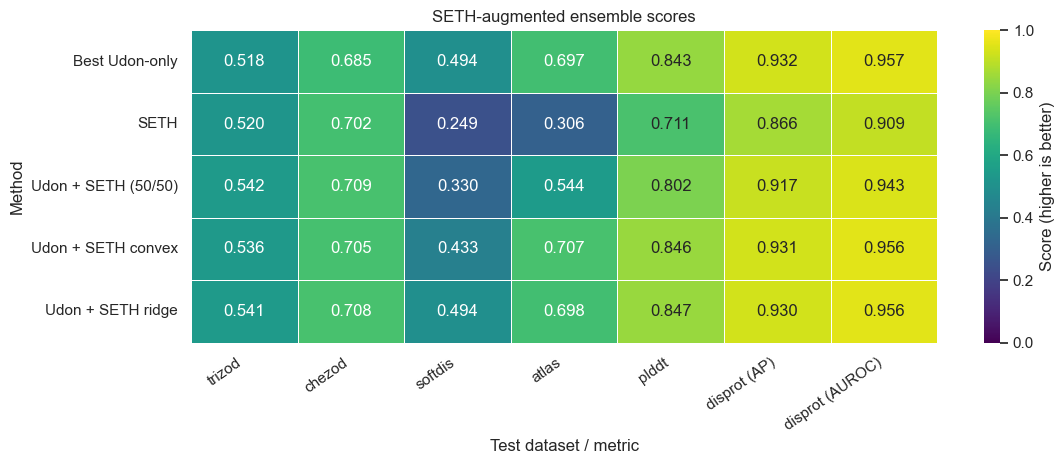

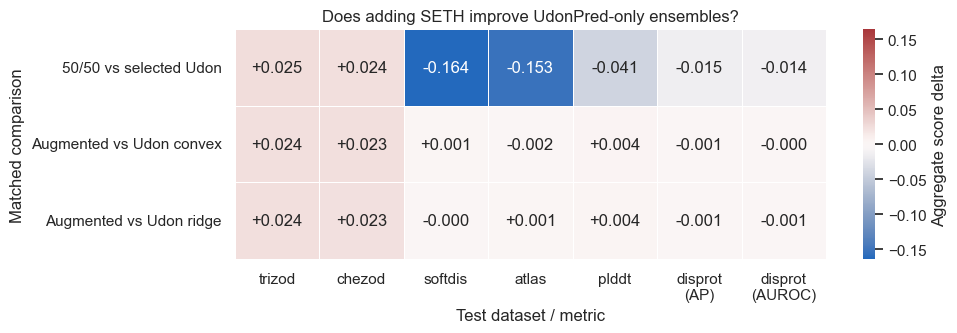

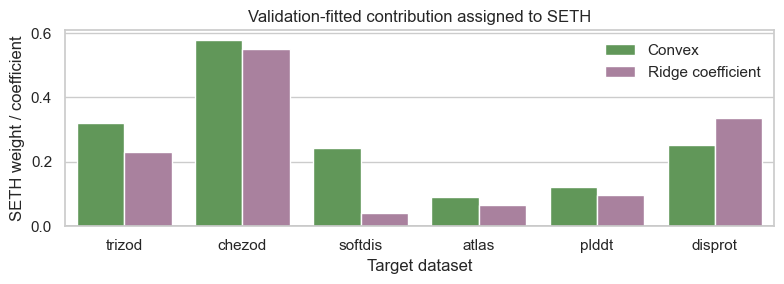

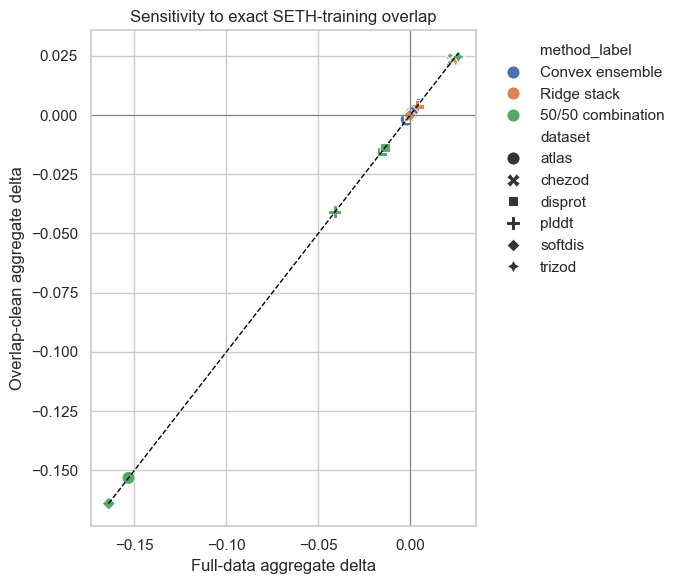

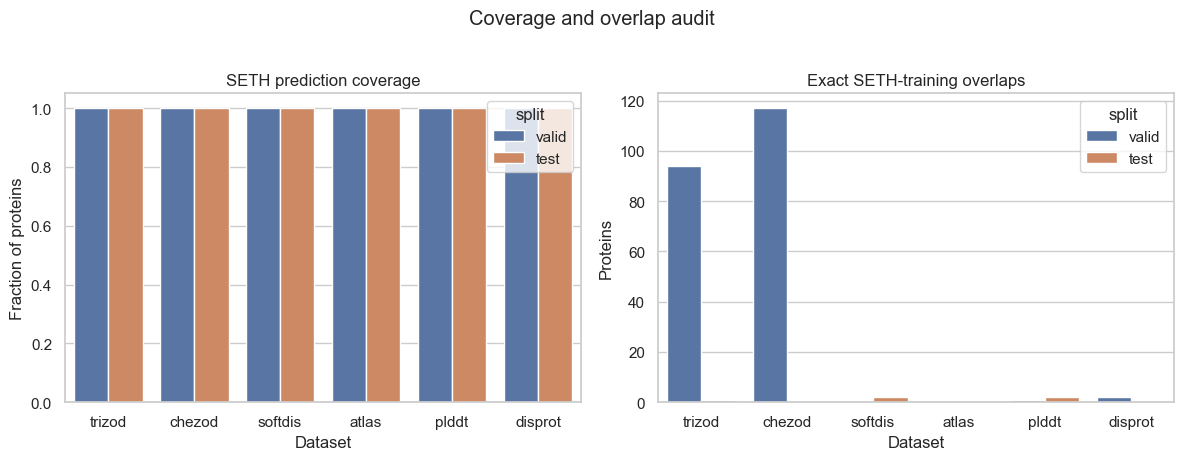

In [13]:
def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(RESULT_DIR / filename, dpi=220, bbox_inches='tight')
    plt.show()


method_labels = {
    'udon_selected_ensemble': 'Best Udon-only', 'seth': 'SETH',
    'fixed_50_50': 'Udon + SETH (50/50)', 
    'augmented_convex': 'Udon + SETH convex',
    'augmented_ridge': 'Udon + SETH ridge',
}
clean_primary = scores_long[(scores_long['scenario'] == 'clean') & scores_long['method'].isin(method_labels)].copy()
clean_primary['method_label'] = clean_primary['method'].map(method_labels)
clean_primary['metric_label'] = clean_primary['metric'].str.replace('\n', ' ', regex=False)
score_heatmap = clean_primary.pivot_table(index='method_label', columns='metric_label', values='score')
score_heatmap = score_heatmap.reindex(index=list(method_labels.values()))
score_heatmap = score_heatmap.reindex(columns=[metric.replace('\n', ' ') for metric in METRIC_COLS])
plt.figure(figsize=(11.5, 4.8))
sns.heatmap(
    score_heatmap,
    annot=True,
    fmt='.3f',
    cmap=BATLOW_CMAP,
    vmin=min(0.0, float(np.nanmin(score_heatmap.to_numpy()))),
    vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Score (higher is better)'},
)
plt.xlabel('Test dataset / metric'); plt.ylabel('Method')
plt.title('SETH-augmented ensemble scores')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
save_plot('clean_scores_grouped.png')

delta_plot = bootstrap_df.query("scenario == 'clean'").copy()
delta_plot['comparison'] = delta_plot['augmented_method'].map({
    'fixed_50_50': '50/50 vs selected Udon', 'augmented_convex': 'Augmented vs Udon convex', 'augmented_ridge': 'Augmented vs Udon ridge'
})
delta_matrix = delta_plot.pivot(index='comparison', columns='metric', values='aggregate_delta').reindex(columns=METRIC_COLS)
annotations = delta_matrix.copy().astype(object)
for comparison in delta_matrix.index:
    for metric in delta_matrix.columns:
        row = delta_plot.query('comparison == @comparison and metric == @metric')
        if row.empty:
            annotations.loc[comparison, metric] = ''
        else:
            marker = {'improves': '', 'degrades': '', 'inconclusive': ''}[row.iloc[0]['support']]
            if row.iloc[0]['validation_policy'] != 'overlap_excluded':
                marker += ''
            annotations.loc[comparison, metric] = f"{row.iloc[0]['aggregate_delta']:+.3f}{marker}"
limit = float(np.nanmax(np.abs(delta_matrix.to_numpy())))
plt.figure(figsize=(10, 3.5))
sns.heatmap(delta_matrix, annot=annotations, fmt='', cmap=BATLOW_DIVERGING_CMAP, center=0, vmin=-limit, vmax=limit, linewidths=.5, cbar_kws={'label': 'Aggregate score delta'})
plt.xlabel('Test dataset / metric'); plt.ylabel('Matched comparison')
plt.title('Does adding SETH improve UdonPred-only ensembles?')
save_plot('clean_delta_heatmap.png')

seth_weights = weights_long.query("scenario == 'clean' and feature == 'SETH'").copy()
seth_weights['method'] = seth_weights['method'].map({'augmented_convex': 'Convex', 'augmented_ridge': 'Ridge coefficient'})
plt.figure(figsize=(8, 3))
sns.barplot(data=seth_weights, x='dataset', y='weight', hue='method', palette=batlow_palette(2))
plt.axhline(0, color='black', linewidth=1); plt.xlabel('Target dataset'); plt.ylabel('SETH weight / coefficient')
plt.title('Validation-fitted contribution assigned to SETH')
plt.legend(frameon=False)
save_plot('seth_weight_contribution.png')

sensitivity = bootstrap_df.pivot_table(index=['dataset', 'metric', 'augmented_method'], columns='scenario', values='aggregate_delta').reset_index()
sensitivity['method_label'] = sensitivity['augmented_method'].map({
    'fixed_50_50': '50/50 combination', 'augmented_convex': 'Convex ensemble', 'augmented_ridge': 'Ridge stack'
})
plt.figure(figsize=(7, 6))
sns.scatterplot(data=sensitivity, x='full', y='clean', hue='method_label', style='dataset', palette=batlow_palette(sensitivity['method_label'].nunique()), s=90)
bounds = [float(np.nanmin(sensitivity[['full', 'clean']].to_numpy())), float(np.nanmax(sensitivity[['full', 'clean']].to_numpy()))]
plt.plot(bounds, bounds, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='grey', linewidth=.8); plt.axvline(0, color='grey', linewidth=.8)
plt.xlabel('Full-data aggregate delta'); plt.ylabel('Overlap-clean aggregate delta')
plt.title('Sensitivity to exact SETH-training overlap')
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('full_vs_clean_sensitivity.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=coverage_df, x='dataset', y='coverage_fraction', hue='split', palette=batlow_palette(coverage_df['split'].nunique()), ax=axes[0])
axes[0].set_ylim(0, 1.05); axes[0].set_title('SETH prediction coverage'); axes[0].set_ylabel('Fraction of proteins'); axes[0].set_xlabel('Dataset')
sns.barplot(data=overlap_df, x='dataset', y='exact_seth_train_overlaps', hue='split', palette=batlow_palette(overlap_df['split'].nunique()), ax=axes[1])
axes[1].set_title('Exact SETH-training overlaps'); axes[1].set_ylabel('Proteins'); axes[1].set_xlabel('Dataset')
fig.suptitle('Coverage and overlap audit', y=1.02)
save_plot('coverage_overlap_summary.png')


## 9. Automated conclusion and artifact checks

In [ ]:
clean_primary_deltas = bootstrap_df[
    (bootstrap_df['scenario'] == 'clean') &
    (bootstrap_df['validation_policy'] == 'overlap_excluded') &
    bootstrap_df.apply(lambda row: row['metric'] == primary_metric(row['dataset']), axis=1)
].copy()
summary = clean_primary_deltas.groupby('augmented_method').agg(
    datasets=('dataset', 'count'),
    mean_aggregate_delta=('aggregate_delta', 'mean'),
    supported_improvements=('support', lambda values: int((values == 'improves').sum())),
    supported_degradations=('support', lambda values: int((values == 'degrades').sum())),
    inconclusive=('support', lambda values: int((values == 'inconclusive').sum())),
).reset_index()
summary.to_csv(RESULT_DIR / 'conclusion_summary.csv', index=False)
display(summary.style.format({'mean_aggregate_delta': '{:+.3f}'}))

print('Primary overlap-clean conclusion:')
for row in summary.itertuples(index=False):
    print(f'- {row.augmented_method}: mean primary-metric delta {row.mean_aggregate_delta:+.3f}; ' f'{row.supported_improvements}/{row.datasets} supported improvements, ' f'{row.supported_degradations}/{row.datasets} supported degradations, {row.inconclusive} inconclusive.')
fallback_datasets = selections_df.query("scenario == 'clean' and validation_policy != 'overlap_excluded'")['dataset'].tolist()
if fallback_datasets:
    print(f"- Excluded from the primary clean conclusion because no overlap-free validation split exists: {', '.join(fallback_datasets)}.")

required_files = [
    'seth_coverage.csv', 'overlap_audit.csv', 'comparison_scores_long.csv', 'comparison_delta_matrix.csv',
    'delta_bootstrap.csv', 'ensemble_weights.csv', 'validation_selections.csv', 'conclusion_summary.csv',
    'clean_scores_grouped.png', 'clean_delta_heatmap.png', 'seth_weight_contribution.png',
    'full_vs_clean_sensitivity.png', 'coverage_overlap_summary.png',
]
missing_or_empty = [name for name in required_files if not (RESULT_DIR / name).is_file() or (RESULT_DIR / name).stat().st_size == 0]
assert not missing_or_empty, f'Missing or empty artifacts: {missing_or_empty}'
assert set(scores_long['scenario']) == {'full', 'clean'}
assert np.all(np.isfinite(scores_long['score']))
assert np.allclose(weights_long.query("method == 'augmented_convex'").groupby(['scenario', 'dataset'])['weight'].sum(), 1.0)
print(f'Artifact verification passed: {len(required_files)} required files are present and non-empty.')


,augmented_method,datasets,mean_aggregate_delta,supported_improvements,supported_degradations,inconclusive
0,augmented_convex,5,+0.005,4,0,1
1,augmented_ridge,5,+0.005,4,0,1
2,fixed_50_50,5,-0.070,1,2,2


Primary overlap-clean conclusion:
- augmented_convex: mean primary-metric delta +0.005; 4/5 supported improvements, 0/5 supported degradations, 1 inconclusive.
- augmented_ridge: mean primary-metric delta +0.005; 4/5 supported improvements, 0/5 supported degradations, 1 inconclusive.
- fixed_50_50: mean primary-metric delta -0.070; 1/5 supported improvements, 2/5 supported degradations, 2 inconclusive.
- Excluded from the primary clean conclusion because no overlap-free validation split exists: chezod.
Artifact verification passed: 13 required files are present and non-empty.
